# Project 1 - 2026

Work in groups of 2-5. Prepare ~10 slides where one slide describes your setup and analysis, main results, challenges/suprises and take-home message.

Everyone should do the first part of the project. You can then choose from one of the three themes for part 2.

You will be working with a subset of the MNIST data set. 

For all tasks, you have to repeat the exercise in order to be able to draw conclusions. That is, one single run of a data analysis task or simulation has very limited information so repeat a few times to ensure you are not drawing conclusions based on a random "fluke".

## Introduction

The first time when looking at a csv dataset, it can be benefical to load it in using pandas, to get a sense of the datas content.

Shape images (before): (10000, 784)
Shape labels (before): (10000, 1)
Shape images (after): (2000, 784)
Shape labels (after): (2000, 1)


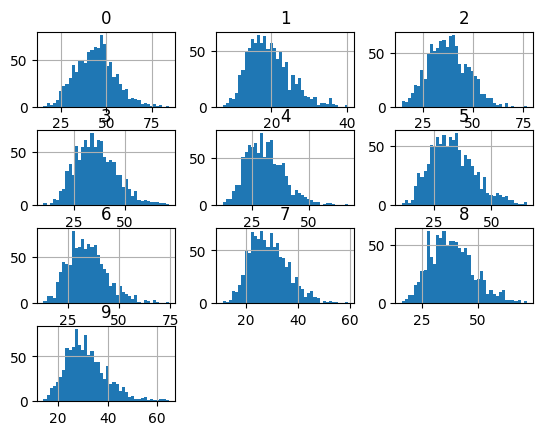

In [260]:
# To run this notebook yourself, the data needs to be unzipped and 
# the path variable specified to point to the unzipped data folder.
# Here we place it in the same folder as the zipped data.

import pandas as pd

images = pd.read_csv(r"mnist_large\images.csv", sep=",", index_col=0)
labels = pd.read_csv(r"mnist_large\labels.csv", sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

print(f"Shape images (before): {images.shape}")
print(f"Shape labels (before): {labels.shape}")

# To sort by a specific label:
mask = labels["label"].isin([0,9])

images_0_9 = images.loc[mask].copy()
labels_0_9 = labels.loc[mask].copy()

print(f"Shape images (after): {images_0_9.shape}")
print(f"Shape labels (after): {labels_0_9.shape}")

# To check the class labels:
labels["label"].value_counts()

# Compare histograms for pixel intensity betwen classes
df = images.join(labels) 
df["mean_intensity"] = images.mean(axis=1)

df.pivot(columns="label", values="mean_intensity").hist(bins=40);

For dealing with images, which are not particularly well suited in tabular formats, numpy is a better tool

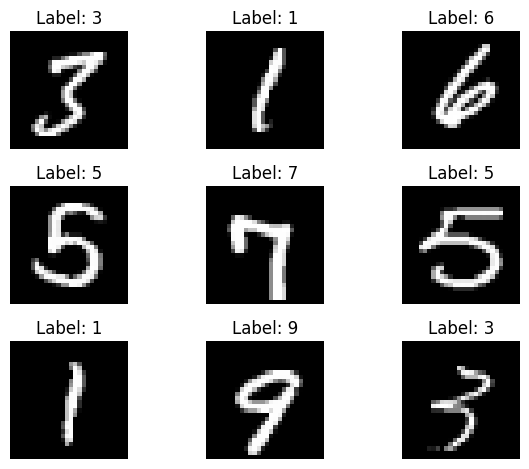

In [261]:
import matplotlib.pyplot as plt
import numpy as np

images = np.array(images)
labels = np.array(labels).ravel()

n_images = images.shape[0]
n_samples = 9

idx = np.random.choice(n_images, size = n_samples, replace = False)
images_sub = images[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(3, 3)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(28,28)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

Digit = 1 | Train (n): 750, Test (n): 250, Train (%): 0.75
Digit = 5 | Train (n): 750, Test (n): 250, Train (%): 0.75
Digit = 7 | Train (n): 750, Test (n): 250, Train (%): 0.75


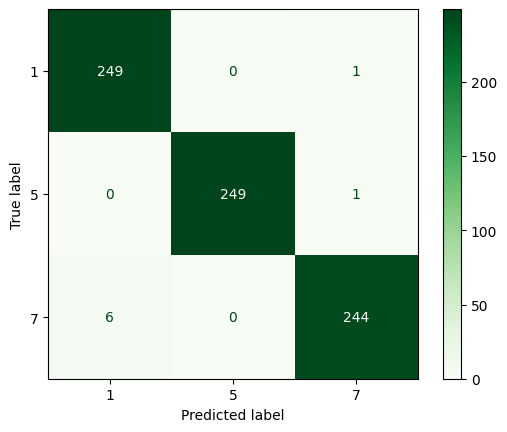

In [262]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Subet on three classes (NOTE: We are now doing the susbetting in numpy and not pandas)
digits = [1, 5, 7]
mask = (labels == digits[0]) | (labels == digits[1]) | (labels == digits[2]) 
images_sub = images[mask]
labels_sub = labels[mask]

# Create a test and train set
x_train, x_test, y_train, y_test = train_test_split(images_sub, labels_sub, test_size=0.25, stratify=labels_sub)

# Sanity check
for digit in digits:
    train_digits = np.sum(y_train == digit)
    test_digits = np.sum(y_test == digit)
    prop = train_digits / (train_digits + test_digits)
    print(f"Digit = {digit} | Train (n): {train_digits}, Test (n): {test_digits}, Train (%): {prop}")


# Apply to train
neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(x_train, y_train)

# Predict on test data
preds = neigh.predict(x_test)

cm = confusion_matrix(y_test, preds, labels=digits)
ConfusionMatrixDisplay(cm, display_labels=digits).plot(cmap='Greens')



# Part 1

*Everyone should do this task.*

The purpose of this first exercise is to build a classification pipeline, from data exploration to validation. Remember to split your data into appropriate sets before you start.
You should explore at least 4 *different* classifiers of *different* character.

1. Perform dimension reduction on the data set. Is the data well separated?
2. Train the classifiers using the training data, and perform cross-validation to tune the models that require tuning.
3. Compare the performance of the different classifiers on a test set.

In [263]:
images = images / 255 # Change the image from 0-1

In [264]:
# Train test split data
x_train, x_split, y_train, y_split = train_test_split(images, labels, test_size=0.30, stratify=labels, shuffle=True)
x_val, x_test, y_val, y_test = train_test_split(x_split, y_split, test_size=0.50, shuffle=False)

# Normalise and center the data 
mean = x_train.mean()
std = x_train.std()

print(mean, std)

x_train_norm = (x_train - mean) / std
x_val_norm = (x_val - mean) / std

0.13150294117647066 0.30887157134525844


In [265]:
# Perform dimension reduction PCA, tSNE, UMAP
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE # Did not use, UMAP performed better
from scipy.linalg import svd # Did not use, used linear k-PCA instead
from umap import UMAP
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

n = [5, 10, 15, 20]
# for i in n:
#     pca = PCA(n_components=i)
#     pca_train = pca.fit_transform(x_train_norm)
#     pca_val = pca.transform(x_val_norm) 

#     knn_model = KNeighborsClassifier(n_neighbors=5, weights="distance", algorithm="brute")
#     knn_model.fit(pca_train, y_train)
#     preds_knn = knn_model.predict(pca_val)

#     accuracy_knn = accuracy_score(y_val, preds_knn)
#     print(f"Accuracy for n={i}: {accuracy_knn}") # Best accuracy is for n=20, but n=30 and 50 is also very good.

# for i in n:
#     umap_model = UMAP(n_components=20, random_state=1000, min_dist=0.1, n_neighbors=i)
#     umap_train = umap_model.fit_transform(x_train_norm)
#     umap_val = umap_model.transform(x_val_norm)

#     knn_model = KNeighborsClassifier(n_neighbors=5, weights="distance", algorithm="brute")
#     knn_model.fit(umap_train, y_train)
#     preds_knn = knn_model.predict(umap_val)

#     accuracy_knn = accuracy_score(y_val, preds_knn)
#     print(f"Accuracy for n={i}: {accuracy_knn}") # Best accuracy is for n=20, k=10

C:\Users\wwide\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


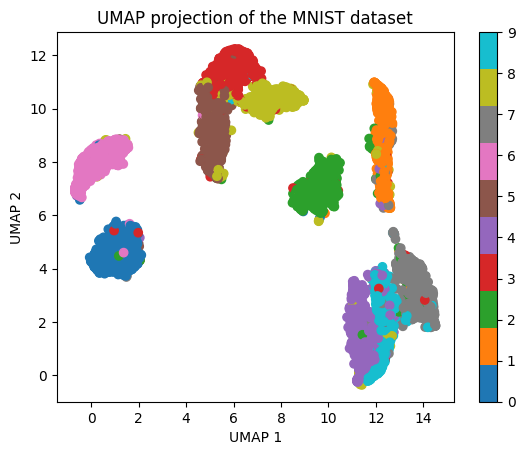

In [266]:
# Visualisation using UMAP
umap_model = UMAP(n_components=2, random_state=1000, min_dist=0.01, n_neighbors=20)
umap_train = umap_model.fit_transform(x_train_norm)
plt.scatter(umap_train[:,0], umap_train[:,1], c=y_train, cmap="tab10", alpha=1)
plt.title("UMAP projection of the MNIST dataset")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(ticks=range(10), alpha=1, cmap="tab10")
plt.show()

In [267]:
umap_model = UMAP(n_components=30, random_state=1000, min_dist=0.1, n_neighbors=20)
umap_train = umap_model.fit_transform(x_train_norm)
umap_val = umap_model.transform(x_val_norm)

pca = PCA(n_components=20, svd_solver= 'full')
pca_train = pca.fit_transform(x_train_norm)
pca_val = pca.transform(x_val_norm) 

C:\Users\wwide\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Notice how UMAP parameters affect the embedding. The key parameters are:
- `n_neighbors`: controls the size of local neighborhood (lower = more local structure)
- `min_dist`: controls how tightly points can cluster together (higher = looser clustering)

In [268]:
# CART
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

cart_model = DecisionTreeClassifier(
    random_state=123,
    max_depth=10,
    min_samples_split=15,
    min_samples_leaf=60,
    splitter="best",
    criterion="entropy"
)
cart_model.fit(umap_train, y_train)

# Prediction
preds_cart = cart_model.predict(umap_val)
accuracy_cart = accuracy_score(y_val, preds_cart)
cross_val_scores = cross_val_score(cart_model, umap_train, y_train, cv=5)
f1 = f1_score(y_val, preds_cart, average="weighted")

print(f"Tree depth: {cart_model.get_depth()}")
print(f"Number of leaves: {cart_model.get_n_leaves()}")
print(f"Accuracy: {accuracy_cart:.4f}")
print(f"Cross-validation scores: {cross_val_scores.mean()}")
print(f"F1 Score: {f1:.4f}")

Tree depth: 9
Number of leaves: 67
Accuracy: 0.8967
Cross-validation scores: 0.9269999999999999
F1 Score: 0.8968


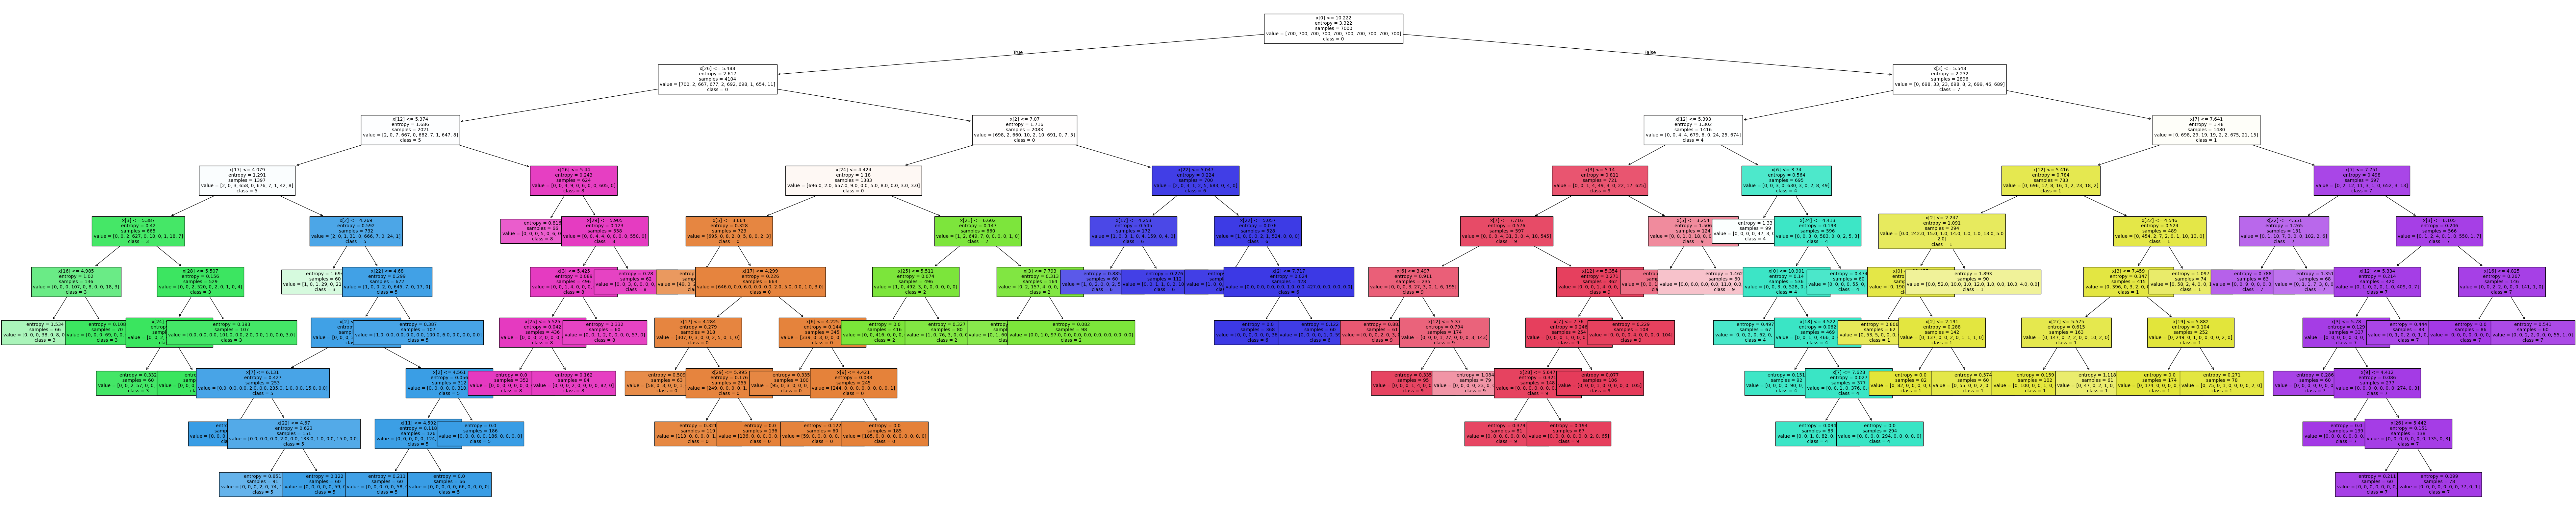

In [269]:
fig, ax = plt.subplots(figsize=(100,20))
plot_tree(cart_model, filled=True, ax=ax, class_names=[str(i) for i in np.unique(y_train)], fontsize=10)
plt.savefig("cart_tree_1.png")
plt.show()

Vissa löv skulle kunna prunas tidigare än att sätta max depth vid 8. Vi ser att vissa grenar tidigt hittar "alla" sina klasser medans andra exampelvis 4 och 9 strugglar med att sorteras upp. Overfit när man låter ex. 1 och 0 fortsätta splitta trots att den klassificerat alla?

In [270]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=123, l1_ratio=0, max_iter=5000, solver="lbfgs")
log_reg.fit(umap_train, y_train)
preds_log_reg = log_reg.predict(umap_val)
accuracy_log_reg = accuracy_score(y_val, preds_log_reg)
f1_log_reg = f1_score(y_val, preds_log_reg, average="weighted")

print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")
print(f"Logistic Regression F1 Score: {f1_log_reg:.4f}")

Logistic Regression Accuracy: 0.9100
Logistic Regression F1 Score: 0.9100


KNN Accuracy: 0.9487
KNN F1 Score: 0.9485
[[160   0   0   0   0   0   0   0   1   0]
 [  0 137   1   0   0   0   0   1   0   0]
 [  1   0 139   1   0   0   0   3   2   0]
 [  0   1   2 136   0   2   1   1   6   1]
 [  0   1   1   0 135   0   1   0   0   6]
 [  1   2   0   2   0 135   1   0   1   1]
 [  0   0   0   0   0   0 150   0   0   0]
 [  0   3   1   0   5   0   0 140   0   2]
 [  0   3   0   2   1   1   3   2 139   1]
 [  0   0   0   2   6   2   0   2   0 152]]


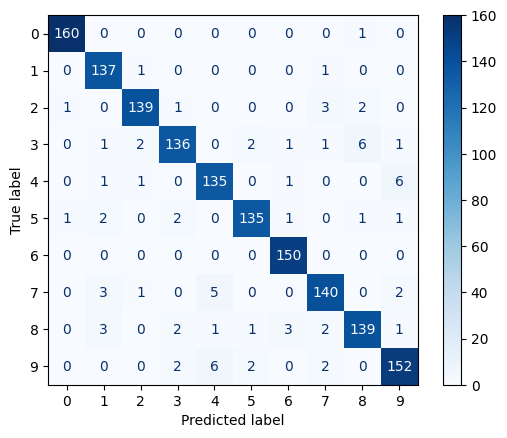

In [271]:
from sklearn.neighbors import KNeighborsClassifier

pca = PCA(n_components=40)
pca_train = pca.fit_transform(x_train_norm)
pca_val = pca.transform(x_val_norm) 

knn_model = KNeighborsClassifier(n_neighbors=5, weights="distance", algorithm="brute")
knn_model.fit(pca_train, y_train)
preds_knn = knn_model.predict(pca_val)

accuracy_knn = accuracy_score(y_val, preds_knn)
f1_knn = f1_score(y_val, preds_knn, average="weighted")

print(f"KNN Accuracy: {accuracy_knn:.4f}")
print(f"KNN F1 Score: {f1_knn:.4f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_knn = confusion_matrix(y_val, preds_knn, labels=np.unique(y_train))
print(cm_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=np.unique(y_train)).plot(cmap='Blues')

In [272]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    random_state=123, 
    n_estimators=100, 
    max_depth=10, 
    min_samples_split=10, 
    min_samples_leaf=5, 
    max_features="sqrt", 
    n_jobs=-1
    )
rf_model.fit(umap_train, y_train)

# Predictions 
rf_preds = rf_model.predict(umap_val)
accuracy_rf = accuracy_score(y_val, rf_preds)
f1_rf = f1_score(y_val, rf_preds, average="weighted")

print("Numbers of trees: 100")
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest F1 Score: {f1_rf:.4f}")
print("Total number of features:", umap_train.shape[1])

Numbers of trees: 100
Random Forest Accuracy: 0.9140
Random Forest F1 Score: 0.9142
Total number of features: 30


Validation using Test data

In [273]:
x_test_norm = (x_test - mean) / std
pca_test = pca.transform(x_test_norm)
umap_test = umap_model.transform(x_test_norm)

Testing the different modells 

[[135   0   0   0   0   0   2   0   1   1]
 [  0 160   0   0   0   0   0   0   0   1]
 [  2   2 145   1   0   0   0   2   1   1]
 [  2   0   0 142   0   3   0   0   3   0]
 [  1   0   0   0 147   0   3   0   0   5]
 [  0   1   1   1   1 150   1   0   1   1]
 [  1   0   0   0   0   2 147   0   0   0]
 [  0   2   0   0   1   0   0 142   0   4]
 [  1   4   0   1   0   0   1   0 140   1]
 [  2   0   0   2   4   0   0   2   2 124]]
KNN Accuracy: 0.9547
KNN F1 Score: 0.9547

Logistic Regression Accuracy: 0.9227
Logistic Regression F1 Score: 0.9230

Numbers of trees: 100
Random Forest Accuracy: 0.9247
Random Forest F1 Score: 0.9249
Total number of features: 30

Tree depth: 9
Number of leaves: 67
Cart Accuracy: 0.9047
Cart Cross-validation scores: 0.8859999999999999
F1 Score: 0.9050


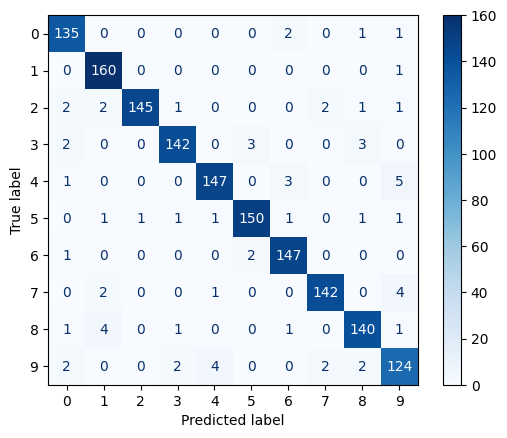

In [274]:

#knn
preds_knn = knn_model.predict(pca_test)
accuracy_knn = accuracy_score(y_test, preds_knn)
f1_knn = f1_score(y_test, preds_knn, average="weighted")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_knn = confusion_matrix(y_test, preds_knn, labels=np.unique(y_train))
print(cm_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=np.unique(y_train)).plot(cmap='Blues')

print(f"KNN Accuracy: {accuracy_knn:.4f}")
print(f"KNN F1 Score: {f1_knn:.4f}")
print()


#logistic regresion
preds_log_reg = log_reg.predict(umap_test)
accuracy_log_reg = accuracy_score(y_test, preds_log_reg)
f1_log_reg = f1_score(y_test, preds_log_reg, average="weighted")

print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")
print(f"Logistic Regression F1 Score: {f1_log_reg:.4f}")
print()


# Random forest
rf_preds = rf_model.predict(umap_test)
accuracy_rf = accuracy_score(y_test, rf_preds)
f1_rf = f1_score(y_test, rf_preds, average="weighted")

print("Numbers of trees: 100")
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest F1 Score: {f1_rf:.4f}")
print("Total number of features:", umap_train.shape[1])
print()



#CART
preds_cart = cart_model.predict(umap_test)
accuracy_cart = accuracy_score(y_test, preds_cart)
cross_val_scores = cross_val_score(cart_model, umap_test, y_test, cv=5)
f1 = f1_score(y_test, preds_cart, average="weighted")

print(f"Tree depth: {cart_model.get_depth()}")
print(f"Number of leaves: {cart_model.get_n_leaves()}")
print(f"Cart Accuracy: {accuracy_cart:.4f}")
print(f"Cart Cross-validation scores: {cross_val_scores.mean()}")
print(f"F1 Score: {f1:.4f}")



## Part 2 - Themes
Choose ***one*** theme of the three and perform ***all*** tasks as described in this theme.

### Theme 1 - Class imbalance

For simplicity, restrict your data set to only 0s, 1s, and 2s. 

Create class imbalances in two different ways:
1. Keep the size of two classes and downsample the third.
2. Keep the size of one class and downsample the other two. 
You should explore at several levels of downsampling, from severe to mild. 

For each case, redo Part 1.

Compare class-specific accuracy and overall accuracy for the different classifiers. Do some models handle the downsampling better? In the most severe cases, can you see a reason to look at the class-specific accuracies and not just the overall accuracy?

### Theme 2 - Mislabeling

Create a mislabeled data set from the digits data by randomly changing the labels for some of the observations. *Note, you should only create mislabels for your training data - the test data should be clean.*

Redo Part 1 in this setting.

Which methods handle the mislabeling OK? which methods struggle?

You should explore at least 3 levels of mislabeling (some modest, some more severe and some really severe cases), i.e. proportion of mislabeled data. *Please note that your test data should be "clean", i.e. without mislabeling. For each simulation run, make sure you create a clean and separate data set to estimate prediction performance.*

### Theme 3 - Noise and dimension reduction

Add Gaussian noise to 10, 50, and 80 percent of the features (i.e. pixels). *Note, you should add the noise to both the training data and the test data.*

Choose 2 different dimension reduction methods and redo Part 1 with both, in addition to performing classification without any dimension reduction. (Consider how the variance of the noise and standardization of features may impact the outcome.)

How do the different dimension reduction methods compare? How do the different classifiers perform when the noise percentage is increased? Do any of them perform well without dimension reduction? Explain and discuss. 


Modest mislabeling: 1%, 

More severe: 5% and 

Really severe: 25%

# Preprocessing for part 2

In [327]:
images = pd.read_csv(r"mnist_large\images.csv", sep=",", index_col=0)
labels = pd.read_csv(r"mnist_large\labels.csv", sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

images = np.array(images)
labels = np.array(labels).ravel()

images = images / 255 # Change the image from 0-1

In [328]:
# Train test split data
x_train, x_split, y_train, y_split = train_test_split(images, labels, test_size=0.30, stratify=labels, shuffle=True)
x_val, x_test, y_val, y_test = train_test_split(x_split, y_split, test_size=0.50, shuffle=False)

# Normalise and center the data 
mean = x_train.mean()
std = x_train.std()

print(mean, std)

x_train_norm = (x_train - mean) / std
x_val_norm = (x_val - mean) / std
x_test_norm = (x_test - mean) / std

0.1310904233121821 0.30846938355026593


# 1% misslabeling

In [329]:
x_train_norm_1 = x_train_norm.copy()
x_val_norm_1 = x_val_norm.copy()
y_train_1 = y_train.copy()
y_val_1 = y_val.copy()

C:\Users\wwide\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


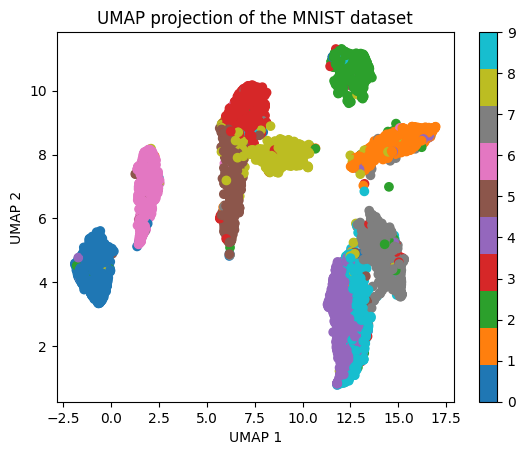

In [330]:
import random

# Mislable 1% of the data i.e. 70 out of 7000
r = 100
for i in range(0, len(y_train_1), r):
    y_train_1[i] = random.randint(0, 9)

umap_model = UMAP(n_components=2, random_state=1000, min_dist=0.01, n_neighbors=20)
umap_train = umap_model.fit_transform(x_train_norm_1)
umap_val = umap_model.transform(x_val_norm_1)
plt.scatter(umap_train[:,0], umap_train[:,1], c=y_train_1, cmap="tab10", alpha=1)
plt.title("UMAP projection of the MNIST dataset")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(ticks=range(10), alpha=1, cmap="tab10")
plt.show()

In [331]:
pca = PCA(n_components=40)
pca_train = pca.fit_transform(x_train_norm_1)
pca_val = pca.transform(x_val_norm_1)

umap_model = UMAP(n_components=30, random_state=1000, min_dist=0.1, n_neighbors=20)
umap_train = umap_model.fit_transform(x_train_norm_1)
umap_val = umap_model.transform(x_val_norm_1)

C:\Users\wwide\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KNN Accuracy: 0.9547
[[154   0   1   0   0   1   0   0   0   0]
 [  0 152   0   0   0   0   0   0   0   0]
 [  1   2 151   0   0   0   1   1   2   0]
 [  1   0   2 130   0   0   0   1   1   2]
 [  0   0   0   0 138   0   0   0   0   6]
 [  0   1   0   2   0 146   1   0   1   1]
 [  0   0   0   0   0   4 139   0   0   0]
 [  0   1   0   0   2   0   0 136   0   3]
 [  0   4   1   4   1   2   3   0 138   3]
 [  1   0   1   2   4   0   0   4   0 148]]


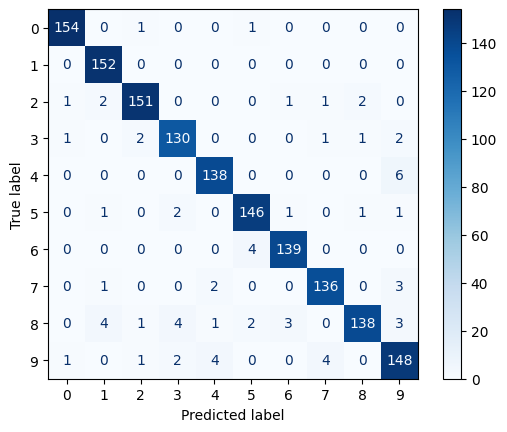

In [332]:
knn_model = KNeighborsClassifier(n_neighbors=5, weights="distance", algorithm="brute")
knn_model.fit(pca_train, y_train_1)
preds_knn = knn_model.predict(pca_val)

accuracy_knn = accuracy_score(y_val_1, preds_knn)

print(f"KNN Accuracy: {accuracy_knn:.4f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_knn = confusion_matrix(y_val_1, preds_knn, labels=np.unique(y_train_1))
print(cm_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=np.unique(y_train_1)).plot(cmap='Blues')

Tree depth: 10
Number of leaves: 79
Accuracy: 0.9033
Cross-validation scores: [0.90357143 0.92071429 0.91642857 0.92571429 0.91785714]
[[153   0   1   0   0   1   1   0   0   0]
 [  0 151   0   0   1   0   0   0   0   0]
 [  3  13 129   1   0   1   1   5   5   0]
 [  2   1   0 119   0   5   0   4   5   1]
 [  0   3   0   0 132   0   0   2   0   7]
 [  1   2   0   4   0 140   1   2   1   1]
 [  0   0   1   0   0   2 140   0   0   0]
 [  0   2   0   0   2   0   0 133   0   5]
 [  0  13   0   4   4   5   3   1 124   2]
 [  2   0   0   1   6   0   0  17   0 134]]


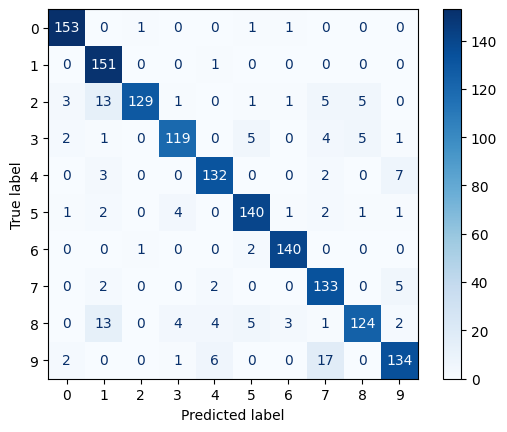

In [333]:
# CART
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

cart_model = DecisionTreeClassifier(
    random_state=123,
    max_depth=10,
    min_samples_split=15,
    min_samples_leaf=60,
    splitter="best",
    criterion="entropy"
)
cart_model.fit(umap_train, y_train_1)

# Prediction
preds_cart = cart_model.predict(umap_val)
accuracy_cart = accuracy_score(y_val_1, preds_cart)
cross_val_scores = cross_val_score(cart_model, umap_train, y_train_1, cv=5)

print(f"Tree depth: {cart_model.get_depth()}")
print(f"Number of leaves: {cart_model.get_n_leaves()}")
print(f"Accuracy: {accuracy_cart:.4f}")
print(f"Cross-validation scores: {cross_val_scores}")

cm_cart = confusion_matrix(y_val_1, preds_cart, labels=np.unique(y_train_1))
print(cm_cart)
ConfusionMatrixDisplay(cm_cart, display_labels=np.unique(y_train_1)).plot(cmap='Blues')

Logistic Regression Accuracy: 0.8987
[[151   0   1   0   1   2   1   0   0   0]
 [  0 148   0   0   1   1   0   0   2   0]
 [  4   2 129   4   0   2   2   3  11   1]
 [  1   0   3 115   0   8   2   4   2   2]
 [  0   0   1   0 135   0   1   1   1   5]
 [  2   1   1   5   3 127   4   0   5   4]
 [  0   0   0   0   2   3 135   0   2   1]
 [  0   0   2   1   2   1   0 133   1   2]
 [  0   5   1   4   0   7   2   0 133   4]
 [  1   0   1   3   5   2   0   4   2 142]]


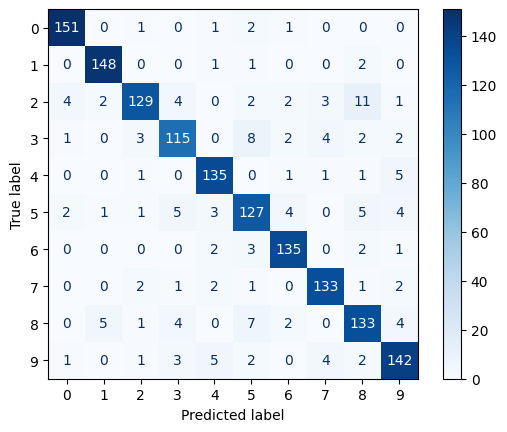

In [334]:
log_reg = LogisticRegression(random_state=123, l1_ratio=0, max_iter=5000, solver="lbfgs")
log_reg.fit(pca_train, y_train_1)
preds_log_reg = log_reg.predict(pca_val)
accuracy_log_reg = accuracy_score(y_val_1, preds_log_reg)

print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")
cm_log = confusion_matrix(y_val_1, preds_log_reg, labels=np.unique(y_train_1))
print(cm_log)
ConfusionMatrixDisplay(cm_log, display_labels=np.unique(y_train_1)).plot(cmap='Blues')

Numbers of trees: 100
Random Forest Accuracy: 0.8767
Total number of features: 40
[[140   0   2   0   1   5   4   0   3   1]
 [  0 149   2   0   0   0   0   0   1   0]
 [  2   1 133   3   2   0   2   0  15   0]
 [  0   0   5 115   0   8   1   2   5   1]
 [  0   1   1   0 131   0   1   0   2   8]
 [  0   0   1   8   5 125   5   0   6   2]
 [  2   1   0   0   0   3 136   0   1   0]
 [  1   2   2   0   2   1   1 125   4   4]
 [  0   5   1   9   2   5   3   0 126   5]
 [  3   0   1   2   8   2   0   3   6 135]]


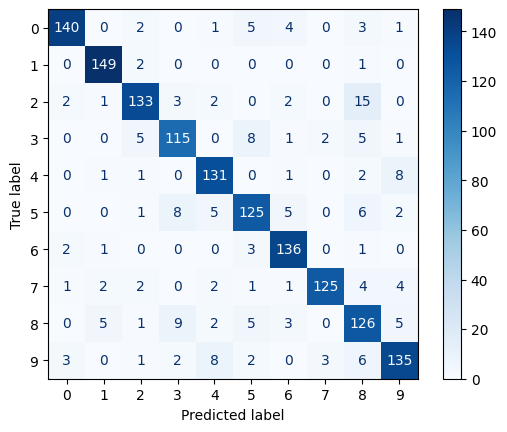

In [335]:
rf_model = RandomForestClassifier(
    random_state=123, 
    n_estimators=100, 
    max_depth=10, 
    min_samples_split=10, 
    min_samples_leaf=5, 
    max_features="sqrt", 
    n_jobs=-1
    )
rf_model.fit(pca_train, y_train_1)

# Predictions 
rf_preds = rf_model.predict(pca_val)
accuracy_rf = accuracy_score(y_val_1, rf_preds)

print("Numbers of trees: 100")
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("Total number of features:", pca_train.shape[1])
cm_rf = confusion_matrix(y_val_1, rf_preds, labels=np.unique(y_train_1))
print(cm_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=np.unique(y_train_1)).plot(cmap='Blues')

In [336]:
x_test_norm = (x_test - mean) / std
pca_test = pca.transform(x_test_norm)
umap_test = umap_model.transform(x_test_norm)

[[12 17 11 10 21 16 10 18  9 20]
 [15 12 12 13 19 18 15 17 17 10]
 [21 12 14 17 15 12 14 13  8 16]
 [17 14 20 16 15 13 19 15 16 18]
 [15 14 19 17  9 21 15 12 16 18]
 [14 23 16 15 12 14 22 10  8 14]
 [16 19 19 10 20 11 12 17 14 19]
 [18 12 18 13 12 17 19 13 19 17]
 [13 21 13 14 11 13 12 15 21 11]
 [16 16 14 13 11 18  6 12 14 20]]
KNN Accuracy: 0.9507
CART Accuracy: 0.8980
Logistic Regression Accuracy: 0.8907
Random Forest Accuracy: 0.8860


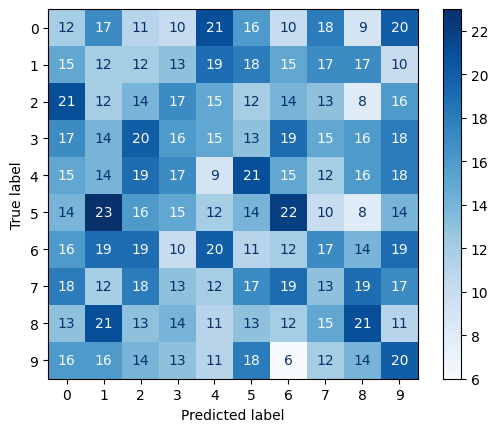

In [ ]:

#KNN
preds_knn = knn_model.predict(pca_test)
accuracy_knn = accuracy_score(y_test, preds_knn)

cm_knn = confusion_matrix(y_test, preds_knn, labels=np.unique(y_train_1))
print(cm_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=np.unique(y_train_1)).plot(cmap='Blues')
print(f"KNN Accuracy: {accuracy_knn:.4f}")

#CART
preds_cart = cart_model.predict(umap_test)
accuracy_cart = accuracy_score(y_test, preds_cart)
print(f"CART Accuracy: {accuracy_cart:.4f}")


#Log reg
preds_log_reg = log_reg.predict(pca_test)
accuracy_log_reg = accuracy_score(y_test, preds_log_reg)
print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")


#Random forest
rf_preds = rf_model.predict(pca_test)
accuracy_rf = accuracy_score(y_test, rf_preds)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

In [338]:
x_train_norm_5 = x_train_norm.copy()
x_val_norm_5 = x_val_norm.copy()
y_train_5 = y_train.copy()
y_val_5 = y_val.copy()

C:\Users\wwide\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


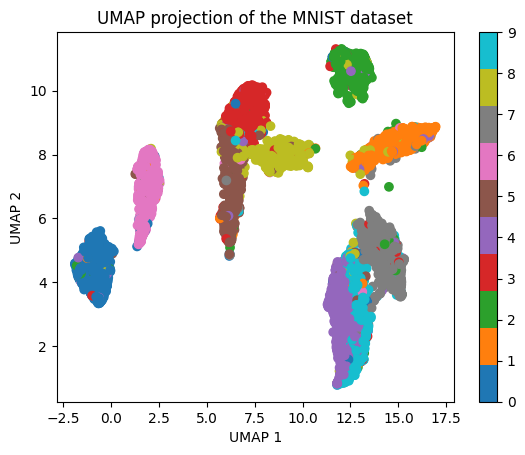

In [339]:
# Mislable 5% of the data i.e. 350 out of 7000
r = 20
for i in range(0, len(y_train_5), r):
    y_train_5[i] = random.randint(0, 9)
    import random

umap_model = UMAP(n_components=2, random_state=1000, min_dist=0.01, n_neighbors=20)
umap_train = umap_model.fit_transform(x_train_norm_5)




plt.scatter(umap_train[:,0], umap_train[:,1], c=y_train_5, cmap="tab10", alpha=1)
plt.title("UMAP projection of the MNIST dataset")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(ticks=range(10), alpha=1, cmap="tab10")
plt.show()

In [340]:
pca = PCA(n_components=50)
pca_train = pca.fit_transform(x_train_norm_5)
pca_val = pca.transform(x_val_norm_5) 

umap_model = UMAP(n_components=30, random_state=1000, min_dist=0.1, n_neighbors=20)
umap_train = umap_model.fit_transform(x_train_norm_5)
umap_val = umap_model.transform(x_val_norm_5)

C:\Users\wwide\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KNN Accuracy: 0.9533
[[154   0   1   0   0   1   0   0   0   0]
 [  0 152   0   0   0   0   0   0   0   0]
 [  1   2 150   0   0   0   0   3   2   0]
 [  1   0   3 126   0   1   0   1   3   2]
 [  0   0   0   0 139   0   0   0   0   5]
 [  0   1   0   1   0 147   1   0   1   1]
 [  0   0   0   0   0   4 139   0   0   0]
 [  0   1   0   0   0   0   0 137   0   4]
 [  0   4   1   4   1   4   2   0 137   3]
 [  3   0   0   1   2   0   0   5   0 149]]


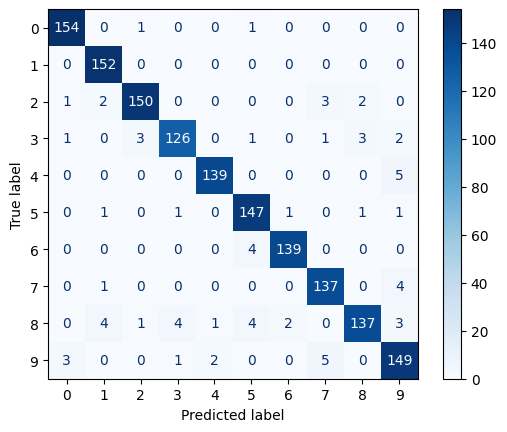

In [341]:



knn_model = KNeighborsClassifier(n_neighbors=5, weights="distance", algorithm="brute")
knn_model.fit(pca_train, y_train_5)
preds_knn = knn_model.predict(pca_val)

accuracy_knn = accuracy_score(y_val_5, preds_knn)

print(f"KNN Accuracy: {accuracy_knn:.4f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_knn = confusion_matrix(y_val_5, preds_knn, labels=np.unique(y_train_5))
print(cm_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=np.unique(y_train_5)).plot(cmap='Blues')

In [342]:
cart_model = DecisionTreeClassifier(
    random_state=123,
    max_depth=10,
    min_samples_split=15,
    min_samples_leaf=60,
    splitter="best",
    criterion="entropy"
)
cart_model.fit(umap_train, y_train_5)

# Prediction
preds_cart = cart_model.predict(umap_val)
accuracy_cart = accuracy_score(y_val_5, preds_cart)
cross_val_scores = cross_val_score(cart_model, umap_train, y_train_5, cv=5)

print(f"Tree depth: {cart_model.get_depth()}")
print(f"Number of leaves: {cart_model.get_n_leaves()}")
print(f"Accuracy: {accuracy_cart:.4f}")
print(f"Cross-validation scores: {cross_val_scores}")

log_reg = LogisticRegression(random_state=123, l1_ratio=0, max_iter=5000, solver="lbfgs")
log_reg.fit(pca_train, y_train_5)
preds_log_reg = log_reg.predict(pca_val)
accuracy_log_reg = accuracy_score(y_val_5, preds_log_reg)

print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")

rf_model = RandomForestClassifier(
    random_state=123, 
    n_estimators=100, 
    max_depth=10, 
    min_samples_split=10, 
    min_samples_leaf=5, 
    max_features="sqrt", 
    n_jobs=-1
    )
rf_model.fit(pca_train, y_train_5)

# Predictions 
rf_preds = rf_model.predict(pca_val)
accuracy_rf = accuracy_score(y_val_5, rf_preds)

print("Numbers of trees: 100")
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("Total number of features:", pca_train.shape[1])



Tree depth: 10
Number of leaves: 93
Accuracy: 0.8933
Cross-validation scores: [0.87285714 0.885      0.89214286 0.89285714 0.88285714]
Logistic Regression Accuracy: 0.8973
Numbers of trees: 100
Random Forest Accuracy: 0.8900
Total number of features: 50


Test


In [343]:
x_test_norm = (x_test - mean) / std
pca_test = pca.transform(x_test_norm)
umap_test = umap_model.transform(x_test_norm)

[[141   0   0   1   0   0   2   0   0   0]
 [  0 147   1   0   0   0   0   0   0   0]
 [  1   2 135   1   1   0   0   2   0   0]
 [  0   0   2 148   0   6   0   2   3   2]
 [  0   3   0   0 146   0   0   1   0   6]
 [  1   2   0   1   1 139   0   1   2   1]
 [  2   0   0   0   0   3 152   0   0   0]
 [  0   4   0   1   2   0   0 149   0   2]
 [  0   1   0   2   1   4   1   1 133   1]
 [  1   0   0   1   4   0   1   1   1 131]]
KNN Accuracy: 0.9473
CART Accuracy: 0.8960
Logistic Regression Accuracy: 0.8820
Random Forest Accuracy: 0.8953


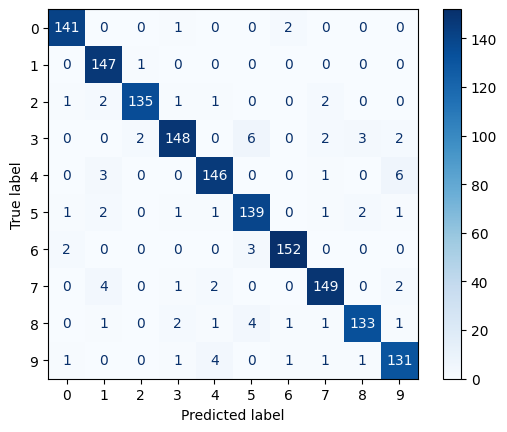

In [344]:

#KNN
preds_knn = knn_model.predict(pca_test)
accuracy_knn = accuracy_score(y_test, preds_knn)

cm_knn = confusion_matrix(y_test, preds_knn, labels=np.unique(y_train_5))
print(cm_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=np.unique(y_train_5)).plot(cmap='Blues')
print(f"KNN Accuracy: {accuracy_knn:.4f}")

#CART
preds_cart = cart_model.predict(umap_test)
accuracy_cart = accuracy_score(y_test, preds_cart)
print(f"CART Accuracy: {accuracy_cart:.4f}")


#Log reg
preds_log_reg = log_reg.predict(pca_test)
accuracy_log_reg = accuracy_score(y_test, preds_log_reg)
print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")


#Random forest
rf_preds = rf_model.predict(pca_test)
accuracy_rf = accuracy_score(y_test, rf_preds)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

# 25% misslabeling

In [345]:
x_train_norm_20 = x_train_norm.copy()
x_val_norm_20 = x_val_norm.copy()
y_train_20 = y_train.copy()
y_val_20 = y_val.copy()

C:\Users\wwide\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


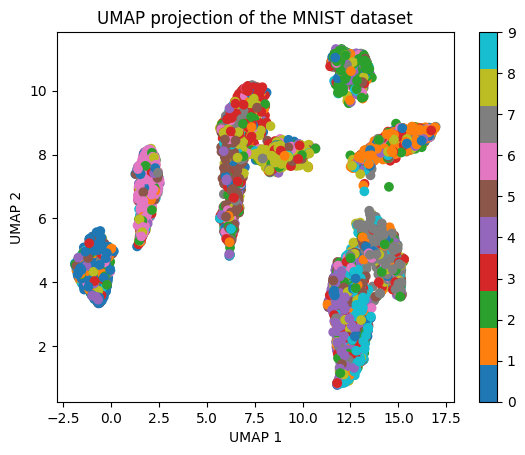

In [346]:
# Mislable 25% of the data i.e. 1750 out of 7000
r = 2
for i in range(0, len(y_train_20), r):
    y_train_20[i] = random.randint(0, 9)

umap_model = UMAP(n_components=2, random_state=1000, min_dist=0.01, n_neighbors=20)
umap_train = umap_model.fit_transform(x_train_norm_20)
plt.scatter(umap_train[:,0], umap_train[:,1], c=y_train_20, cmap="tab10", alpha=1)
plt.title("UMAP projection of the MNIST dataset")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(ticks=range(10), alpha=1, cmap="tab10")
plt.show()

In [347]:
pca = PCA(n_components=60)
pca_train = pca.fit_transform(x_train_norm_20)
pca_val = pca.transform(x_val_norm_20) 

umap_model = UMAP(n_components=30, random_state=1000, min_dist=0.1, n_neighbors=20)
umap_train = umap_model.fit_transform(x_train_norm_20)
umap_val = umap_model.transform(x_val_norm_20)

C:\Users\wwide\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KNN Accuracy: 0.7820
[[125   7   1   4   5   4   3   2   3   2]
 [  5 126   0   1   3   1   5   5   3   3]
 [  6   4 115   1   2   9   6   6   7   2]
 [  4   1   3  99   3   7   4   5   6   5]
 [  3   2   1   1 120   2   2   6   2   5]
 [  5   1   2   7   2 126   4   0   2   3]
 [  0   2   7   1   1   3 117   7   2   3]
 [  4   5   2   1   3   9   2 108   1   7]
 [  3   3   3   8   6   4   6   5 113   5]
 [  1   7   7   3   9   3   1   3   2 124]]


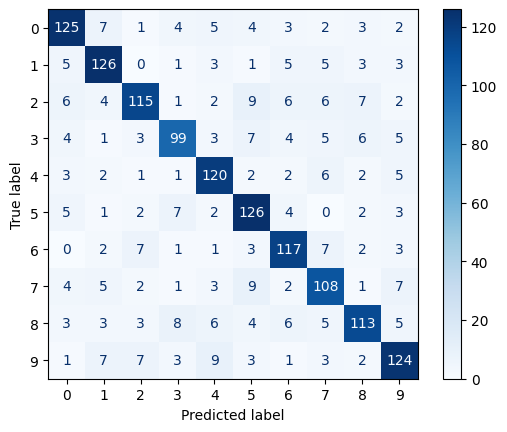

In [348]:
knn_model = KNeighborsClassifier(n_neighbors=5, weights="distance", algorithm="brute")
knn_model.fit(pca_train, y_train_20)
preds_knn = knn_model.predict(pca_val)

accuracy_knn = accuracy_score(y_val_20, preds_knn)

print(f"KNN Accuracy: {accuracy_knn:.4f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_knn = confusion_matrix(y_val_20, preds_knn, labels=np.unique(y_train_20))
print(cm_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=np.unique(y_train_20)).plot(cmap='Blues')

In [349]:
cart_model = DecisionTreeClassifier(
    random_state=123,
    max_depth=10,
    min_samples_split=15,
    min_samples_leaf=60,
    splitter="best",
    criterion="entropy"
)
cart_model.fit(umap_train, y_train_20)

# Prediction
preds_cart = cart_model.predict(umap_val)
accuracy_cart = accuracy_score(y_val_20, preds_cart)
cross_val_scores = cross_val_score(cart_model, umap_train, y_train_20, cv=5)

print(f"Tree depth: {cart_model.get_depth()}")
print(f"Number of leaves: {cart_model.get_n_leaves()}")
print(f"Accuracy: {accuracy_cart:.4f}")
print(f"Cross-validation scores: {cross_val_scores}")

log_reg = LogisticRegression(random_state=123, l1_ratio=0, max_iter=5000, solver="lbfgs")
log_reg.fit(pca_train, y_train_20)
preds_log_reg = log_reg.predict(pca_val)
accuracy_log_reg = accuracy_score(y_val_20, preds_log_reg)

print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")

rf_model = RandomForestClassifier(
    random_state=123, 
    n_estimators=100, 
    max_depth=10, 
    min_samples_split=10, 
    min_samples_leaf=5, 
    max_features="sqrt", 
    n_jobs=-1
    )
rf_model.fit(pca_train, y_train_20)

# Predictions 
rf_preds = rf_model.predict(pca_val)
accuracy_rf = accuracy_score(y_val_20, rf_preds)

print("Numbers of trees: 100")
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("Total number of features:", pca_train.shape[1])
cm_cart = confusion_matrix(y_val_20, preds_cart, labels=np.unique(y_train_20))



Tree depth: 10
Number of leaves: 90
Accuracy: 0.8960
Cross-validation scores: [0.51071429 0.50571429 0.51928571 0.51142857 0.50857143]
Logistic Regression Accuracy: 0.8347
Numbers of trees: 100
Random Forest Accuracy: 0.8740
Total number of features: 60


In [350]:
x_test_norm = (x_test - mean) / std
pca_test = pca.transform(x_test_norm)
umap_test = umap_model.transform(x_test_norm)

[[107   6   1   3   5   8   0   5   6   3]
 [  7 118   2   2   3   3   5   5   3   0]
 [  3   7 104   2   1   6   4   7   6   2]
 [  2   0   3 136   0   5   3   6   7   1]
 [  3   7   4   5 117   3   2   6   2   7]
 [  8   3   4   4   2 106   2   9   3   7]
 [  5   2   3  10   4   2 124   1   2   4]
 [  2   9   3   6   3   7   5 116   2   5]
 [  1   2   3   5   2   3   6   2 117   3]
 [  0   4   4   3  10   3   2   2   4 108]]
KNN Accuracy: 0.7687
CART Accuracy: 0.9000
Logistic Regression Accuracy: 0.8420
Random Forest Accuracy: 0.8760


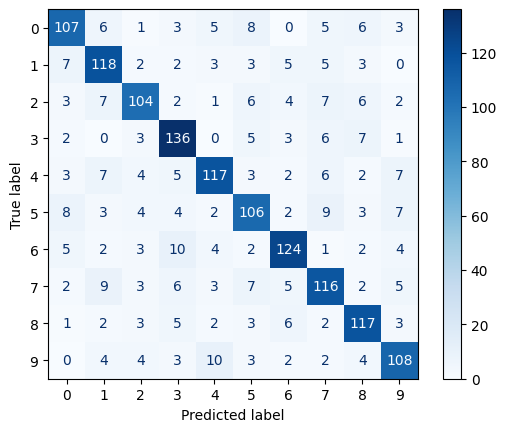

In [351]:

#KNN
preds_knn = knn_model.predict(pca_test)
accuracy_knn = accuracy_score(y_test, preds_knn)

cm_knn = confusion_matrix(y_test, preds_knn, labels=np.unique(y_train_20))
print(cm_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=np.unique(y_train_20)).plot(cmap='Blues')
print(f"KNN Accuracy: {accuracy_knn:.4f}")

#CART
preds_cart = cart_model.predict(umap_test)
accuracy_cart = accuracy_score(y_test, preds_cart)
print(f"CART Accuracy: {accuracy_cart:.4f}")


#Log reg
preds_log_reg = log_reg.predict(pca_test)
accuracy_log_reg = accuracy_score(y_test, preds_log_reg)
print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")


#Random forest
rf_preds = rf_model.predict(pca_test)
accuracy_rf = accuracy_score(y_test, rf_preds)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")